In [1]:
!pip install kaggle

In [2]:
!pip install --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 15.3 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [3]:
import os

os.environ['KAGGLE_API_TOKEN'] = 'KGAT_abaeed85be34aaf5a8fc104267c0a781'
!kaggle datasets download -d oddrationale/mnist-in-csv
!unzip -q mnist-in-csv.zip

Dataset URL: https://www.kaggle.com/datasets/oddrationale/mnist-in-csv
License(s): CC0-1.0
100% 15.2M/15.2M [00:00<00:00, 121MB/s]



In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.ensemble import RandomForestClassifier

In [5]:
df = pd.read_csv('mnist_train.csv')
df.head(2)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df_test = pd.read_csv('mnist_test.csv')
df_test.head(2)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
X_train = df.drop('label', axis=1)
y_train = df['label']
X_test = df_test.drop('label', axis=1)
y_test = df_test['label']

In [8]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

feature_importances = model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

In [9]:
print(importance_df)

    feature  importance
378   14x15    0.011093
433   16x14    0.009297
350   13x15    0.009092
375   14x12    0.008089
437   16x18    0.008030
..      ...         ...
759    28x4    0.000000
761    28x6    0.000000
781   28x26    0.000000
782   28x27    0.000000
783   28x28    0.000000

[784 rows x 2 columns]


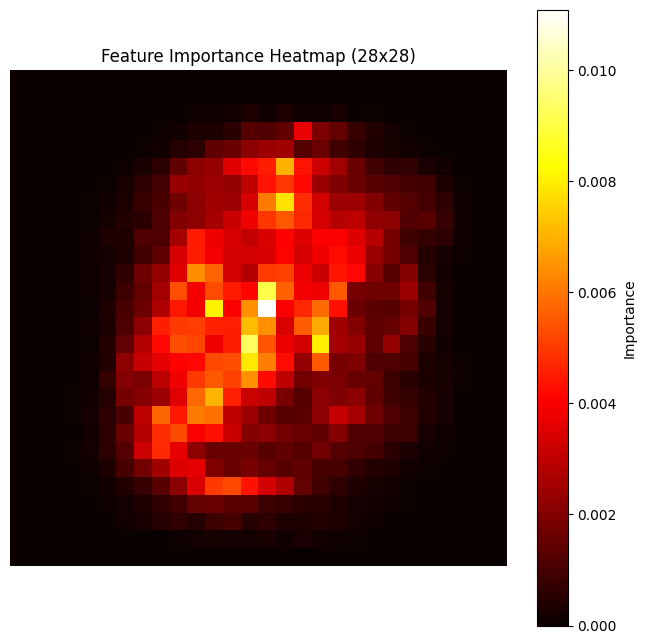

In [10]:
feature_image = np.zeros((28, 28))

for index, row in importance_df.iterrows():
    feature_name = row['feature']
    importance = row['importance']

    try:
        parts = feature_name.split('x')
        row_idx = int(parts[0]) - 1
        col_idx = int(parts[1]) - 1

        if 0 <= row_idx < 28 and 0 <= col_idx < 28:
            feature_image[row_idx, col_idx] = importance
    except (ValueError, IndexError):
        print(f"Warning: Could not parse feature name: {feature_name}")

plt.figure(figsize=(8, 8))
plt.imshow(feature_image, cmap='hot', interpolation='nearest')
plt.title('Feature Importance Heatmap (28x28)')
plt.colorbar(label='Importance')
plt.axis('off')
plt.show()

In [19]:
# Identify features to keep by removing a 2-pixel border from all sides (28x28 -> 24x24)
features_to_keep = []
for r in range(3, 27):  # Rows 3 through 26 (inclusive)
    for c in range(3, 27):  # Columns 3 through 26 (inclusive)
        features_to_keep.append(f'{r}x{c}')

X_train_filtered = X_train[features_to_keep]
X_test_filtered = X_test[features_to_keep]

print(f"Original X_train shape: {X_train.shape}")
print(f"Filtered X_train shape: {X_train_filtered.shape}")
print(f"Original X_test shape: {X_test.shape}")
print(f"Filtered X_test shape: {X_test_filtered.shape}")
print(f"New number of features (should be 24x24 = 576): {len(features_to_keep)}")

Original X_train shape: (60000, 784)
Filtered X_train shape: (60000, 576)
Original X_test shape: (10000, 784)
Filtered X_test shape: (10000, 576)
New number of features (should be 24x24 = 576): 576


### Preparing Data for Neural Network

In [20]:
# Normalize pixel values to 0-1 range
X_train_normalized = X_train_filtered / 255.0
X_test_normalized = X_test_filtered / 255.0

# Reshape data for CNN (assuming 28x28 images, which is standard for MNIST)
# Since we filtered features, we need to check if the remaining features can form a square image.
# If not, a simple dense network might be more appropriate, or we need to Pad.
num_features = X_train_filtered.shape[1]
side_length = int(np.sqrt(num_features))

if side_length * side_length == num_features:
    X_train_reshaped = X_train_normalized.values.reshape(-1, side_length, side_length, 1)
    X_test_reshaped = X_test_normalized.values.reshape(-1, side_length, side_length, 1)
    print(f"Reshaped data to {side_length}x{side_length} for CNN.")
else:
    print(f"Warning: Number of features ({num_features}) is not a perfect square. Cannot directly reshape to a square image for CNN. Proceeding with flattened data for a Dense network.")
    X_train_reshaped = X_train_normalized
    X_test_reshaped = X_test_normalized

y_train_one_hot = keras.utils.to_categorical(y_train, 10)
y_test_one_hot = keras.utils.to_categorical(y_test, 10)

print(f"X_train_reshaped shape: {X_train_reshaped.shape}")
print(f"y_train_one_hot shape: {y_train_one_hot.shape}")

Reshaped data to 24x24 for CNN.
X_train_reshaped shape: (60000, 24, 24, 1)
y_train_one_hot shape: (60000, 10)


### Building and Training the CNN Model

In [21]:
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D,Flatten, LeakyReLU
#CNN model structure
model = Sequential()
model.add(Conv2D(32, (3, 3), activation=LeakyReLU(alpha=0.1), input_shape=(side_length, side_length, 1)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation=LeakyReLU(alpha=0.1)))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())

model.add(Dense(128, activation=LeakyReLU(alpha=0.1)))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 22, 22, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 9, 9, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,306 (591.04 KB)

 Trainable params: 151,306 (591.04 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(X_train_reshaped, y_train_one_hot, epochs=10, validation_data=(X_test_reshaped, y_test_one_hot))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9596 - loss: 0.1328 - val_accuracy: 0.9819 - val_loss: 0.0569
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9863 - loss: 0.0447 - val_accuracy: 0.9881 - val_loss: 0.0342
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9901 - loss: 0.0316 - val_accuracy: 0.9894 - val_loss: 0.0351
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9930 - loss: 0.0220 - val_accuracy: 0.9877 - val_loss: 0.0384
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9944 - loss: 0.0178 - val_accuracy: 0.9909 - val_loss: 0.0325
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9958 - loss: 0.0131 - val_accuracy: 0.9888 - val_loss: 0.0404
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9964 - loss: 0.0108 - val_accuracy: 0.9894 - val_loss: 0.0440
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9966 - loss: 0.0101 

### Evaluate the Model

In [23]:
loss, accuracy = model.evaluate(X_test_reshaped, y_test_one_hot, verbose=0)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

Test Loss: 0.0474
Test Accuracy: 0.9899
